In [1]:
import pandas as pd    
import json
import matplotlib.pyplot as plt
import sys
import os
import importlib
import subprocess

sys.path.append('../utils/')
from vllm_server import *
from notebook_utils import *
import vllm_server
import notebook_utils

importlib.reload(vllm_server)
importlib.reload(notebook_utils)


<module 'notebook_utils' from '/home/p316289/Desktop/work/dl-mig-contention-aware-system/experiments/notebooks/../utils/notebook_utils.py'>

In [3]:
df = pd.read_csv("/tmp/reults/scheduler.csv")
df = df[df["phase"] == "limit"]
df

,timestamp,tick,worker,buckets,usage_bytes,per_tick,max_bucket,phase
620,2026-10-06T10:17:40.182997053Z,621,/tmp/rate-control/rate-control-ops-1,268435456,0,268435456,0,limit
621,2026-10-06T10:17:40.432714993Z,622,/tmp/rate-control/rate-control-ops-1,536870912,0,268435456,0,limit
622,2026-10-06T10:17:40.682399937Z,623,/tmp/rate-control/rate-control-ops-1,805306368,0,268435456,0,limit
623,2026-10-06T10:17:40.932010284Z,624,/tmp/rate-control/rate-control-ops-1,1073741824,0,268435456,0,limit
624,2026-10-06T10:17:41.182778678Z,625,/tmp/rate-control/rate-control-ops-1,1342177280,0,268435456,0,limit
...,...,...,...,...,...,...,...,...
1761,2026-10-06T10:22:25.432859427Z,1762,/tmp/rate-control/rate-control-ops-1,306545876396,0,268435456,0,limit
1762,2026-10-06T10:22:25.682469031Z,1763,/tmp/rate-control/rate-control-ops-1,306814311852,0,268435456,0,limit
1763,2026-10-06T10:22:25.932074614Z,1764,/tmp/rate-control/rate-control-ops-1,307082747308,0,268435456,0,limit
1764,2026-10-06T10:22:26.182877811Z,1765,/tmp/rate-control/rate-control-ops-1,307351182764,0,268435456,0,limit


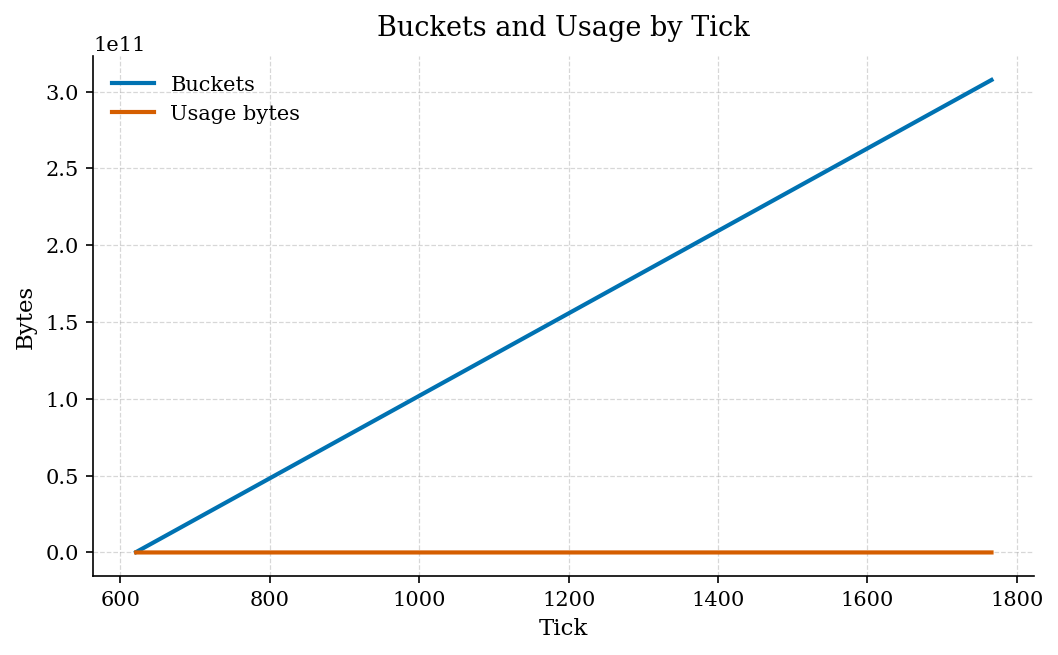

In [5]:
plot_df = df.sort_values("tick")

fig, ax = plt.subplots(figsize=(7.2, 4.5), dpi=150)

ax.plot(
    plot_df["tick"], plot_df["buckets"],
    color="#0072B2", linewidth=2, label="Buckets"
)
ax.plot(
    plot_df["tick"], plot_df["usage_bytes"].cumsum(),
    color="#D55E00", linewidth=2, label="Usage bytes"
)

ax.set_xlabel("Tick", fontsize=11)
ax.set_ylabel("Bytes", fontsize=11)
ax.set_title("Buckets and Usage by Tick", fontsize=13, pad=10)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.grid(True, linestyle="--", linewidth=0.6, alpha=0.5)
ax.legend(frameon=False, fontsize=10)
ax.tick_params(labelsize=10)

fig.tight_layout()
plt.show()